In [5]:
import langchain
import langgraph
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage,AIMessage,HumanMessage
from langgraph.prebuilt import tools_condition,ToolNode
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import START,StateGraph,END
from IPython.display import display,Image
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
from datetime import datetime

### Flow of model

 START -> collect_input -> extract symptoms -> emergency detector

If emergency -> get_location -> hospital_finder -> final_report -> END

If NOT Emeregency -> disease Predcitor -> specialist recommender -> get location -> hospital finder -> explanation generator -> final report -> END

### LLM Setting Up with tool

In [3]:
model = ChatGroq(model="llama-3.1-8b-instant")
tavily = TavilySearchResults(max_results=3)
tool = [tavily]
llm = model.bind_tools(tool)

/var/folders/sy/gfv5kz397jnfgcw3q_d_wjt40000gn/T/ipykernel_2564/484241612.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=3)


### Creating State

In [30]:
class MedicalState(TypedDict):
    collect_input: str
    extract_symptoms: str
    emergency: bool
    get_location: str
    hospitals: str
    disease_predictor: str
    specialist_recommender: str
    final_report: str


### Nodes

In [39]:
def extract_symptoms(state:MedicalState):
    "Extract symptoms from the user data."
    message = [
        SystemMessage(content=f"You are a Medical AI Assistant."),
        HumanMessage(content=f"Find only the Symptoms from the input {state['collect_input']}")
    ]

    result = model.invoke(message)
    return {"extract_symptoms":result.content}

def emergency(state: MedicalState):

    message = [
        HumanMessage(
            content=f"""
            Symptoms: {state['extract_symptoms']}

            Determine whether this is a medical emergency.

            Return ONLY:
            True
            or
            False
            """
        )
    ]

    result = model.invoke(message)

    value = result.content.strip().lower()

    return {
        "emergency": value == "true"
    }

def get_location(state:MedicalState):
    message = [
        HumanMessage(content=f"Extract the address of the user from {state['collect_input']} and return only address.")
    ]
    result = model.invoke(message)
    return {"get_location":result.content}

def hospital_finder(state:MedicalState):
#     message = [ SystemMessage(content=f"""You are an AI Assistant if you need date and time use it {datetime.now()} and return the best answer.
#                               if needed use tools for best result in order to avoid knowledge cut off date,Use Tavily search to find actual hospitals.
# Return hospital name, address and contact number."""),
#         HumanMessage(content=f"""
#             Based on the symptoms {state['extract_symptoms']} and and the urgency from {state["emergency"]}
#             List the nearest hospital using the address {state["get_location"]}
#                 """)
#     ]
    # response = llm.invoke(message)

    # if response.content:
    #     return {"hospitals": response.content}

    # return {"hospitals": "No hospitals found."}

    results = tavily.invoke(
    {
        "query": f"Top emergency hospitals near {state['get_location']}"
    }
)

    return {"hospitals": results}

def disease(state:MedicalState):
    message = [
        HumanMessage(content=f"""
            Based on the Sympotms {state['extract_symptoms']}.
            Predict the User suffering from which disease with confidence score out of 100 in percentage.
            Also write two to five Facts on ground of which you will say suffering to this disease.
""")
    ]
    result = model.invoke(message)
    return {"disease_predictor":result.content}

def specialist(state:MedicalState):
    message = [
        HumanMessage(content=f"""
        Keeping the symptoms and Diseases tell to which specialist i need to connect. for example:
                     Physicia , Neurologist etc.
                     symptoms :{state["extract_symptoms"]}
                     Disease : {state["disease_predictor"]}
""")
    ]

    result = model.invoke(message)
    return {"specialist_recommender":result.content}

def explanation_generator(state: MedicalState):

    disease = state.get("disease_predictor", "Not Applicable (Emergency Case)")

    specialist = state.get(
        "specialist_recommender",
        "Immediate Emergency Care Required"
    )

    hospitals = state.get("hospitals", "No hospitals found")

    message = [
        HumanMessage(
            content=f"""
Generate a final report.

User Query:
{state['collect_input']}

Symptoms:
{state['extract_symptoms']}

Emergency:
{state['emergency']}

Disease:
{disease}

Recommended Specialist:
{specialist}

Nearest Hospitals:
{hospitals}

Generate a clear medical report.
"""
        )
    ]

    result = model.invoke(message)

    return {"final_report": result.content}

def route_emergency(state: MedicalState):

    if state["emergency"]:
        return "emergency_path"

    return "normal_path"





### Building Graph

In [40]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(MedicalState)

# Nodes
builder.add_node("extract_symptoms", extract_symptoms)
builder.add_node("emergency", emergency)
builder.add_node("disease", disease)
builder.add_node("specialist", specialist)
builder.add_node("get_location", get_location)
builder.add_node("hospital_finder", hospital_finder)
builder.add_node("explanation_generator", explanation_generator)

# Initial Flow
builder.add_edge(START, "extract_symptoms")
builder.add_edge("extract_symptoms", "emergency")

# Conditional Branch
builder.add_conditional_edges(
    "emergency",
    route_emergency,
    {
        "emergency_path": "get_location",
        "normal_path": "disease",
    }
)

# Non-emergency path
builder.add_edge("disease", "specialist")
builder.add_edge("specialist", "get_location")

# Common path
builder.add_edge("get_location", "hospital_finder")
builder.add_edge("hospital_finder", "explanation_generator")
builder.add_edge("explanation_generator", END)

# Compile
graph = builder.compile()

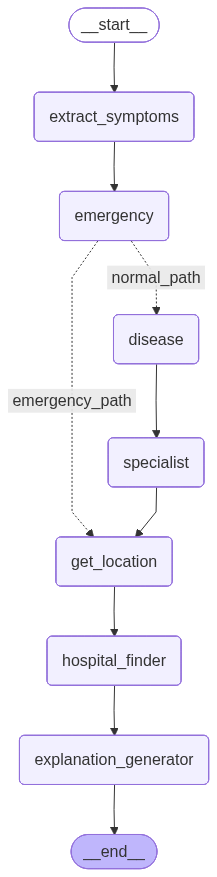

In [41]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
result = graph.invoke({
    "collect_input": """
    My father is 62 years old. He is having severe chest pain radiating to the left arm,
    shortness of breath, excessive sweating and dizziness.
    We are currently at Sector 22, Gurugram.
    """
})


In [43]:
print(result.get("final_report"))

**EMERGENCY MEDICAL REPORT**

**Patient Information:**

* **Name:** [Your Father's Name]
* **Age:** 62 years
* **Location:** Sector 22, Gurugram

**Symptoms:**

1. **Severe chest pain** radiating to the left arm
2. **Shortness of breath**
3. **Excessive sweating**
4. **Dizziness**

**Assessment:**

Based on the symptoms presented, the patient is experiencing a medical emergency. The symptoms are consistent with a cardiovascular event, such as a heart attack or myocardial infarction.

**Emergency Action:**

Immediate emergency care is required. The patient needs to be transported to the nearest hospital for further evaluation and treatment.

**Recommended Specialist:**

Cardiologist

**Nearest Hospitals:**

The following hospitals are located near Sector 22, Gurugram:

1. **Top Super Speciality & Multispeciality Hospital in Gurugram | Park Hospital**
	* Address: [insert address]
	* Phone: +91-8518000000 (Ambulance Services)
	* Distance: [insert distance]
2. **Manipal Hospital Gurugram |

In [46]:
result = graph.invoke({
    "collect_input": """
    I am 28 years old. I have had a sore throat, mild fever,
    runny nose, and dry cough for the last 3 days.
    I live near VPO Kurar , Panipat , Haryana 132103.
    """
})

print(result["final_report"])

**Medical Report**

**Patient Information:**

* Name: [Not Provided]
* Age: 28 Years
* Address: VPO Kurar, Panipat, Haryana 132103

**Chief Complaint:**

The patient presents with the following symptoms:

1. Sore throat
2. Mild fever
3. Runny nose
4. Dry cough

**Clinical History:**

The patient has been experiencing these symptoms for the past 3 days.

**Physical Examination:**

No specific findings were noted during the physical examination.

**Diagnostic Testing:**

None were conducted.

**Differential Diagnosis:**

Based on the symptoms provided, the most likely diagnosis is **Common Cold** with a confidence score of **80%**.

**Supporting Facts:**

1. **Common Cold is a viral infection**: The symptoms listed are typical of a viral infection, which is the most common cause of the common cold.
2. **Dry cough and sore throat are common symptoms**: A dry cough and sore throat are common symptoms of the common cold, especially in the early stages of the illness.
3. **Mild fever is a co

In [45]:
print(result.get("final_report"))

**Medical Report**

**Patient Information**

- **Name:** Anonymous
- **Age:** 28 years
- **Address:** Sector 23, Gurugram
- **Date of Visit:** [Insert Date]

**Chief Complaint**

The patient presents with a sore throat, mild fever, runny nose, and dry cough for the last 3 days.

**History of Present Illness**

The patient reports experiencing a sore throat, mild fever, runny nose, and dry cough for the past 3 days. These symptoms have been persistent and have not shown significant improvement despite self-care measures.

**Physical Examination**

- **Vital Signs:** Temperature (oral): 38.5°C, Pulse: 100 bpm, Respiratory Rate: 20 breaths per minute, Blood Pressure: 120/80 mmHg
- **General Appearance:** The patient appears uncomfortable and has a subtle cough.
- **Respiratory System:** Bilateral lung sounds are clear, and there is no evidence of wheezing or stridor.
- **Throat Examination:** The throat is erythematous, and the tonsils are mildly enlarged.
- **Nasal Examination:** The nas

In [47]:
def agent_response(query):
    result = graph.invoke({
    "collect_input": query
})
    return result.get("final_report")
    

In [48]:
!pip install gradio


  Using cached gradio_client-2.5.0-py3-none-any.whl.metadata (7.1 kB)
  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached hf_gradio-0.4.1-py3-none-any.whl.metadata (428 bytes)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached safehttpx-0.1.7-py3-none-any.whl.metadata (4.2 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached tomlkit-0.14.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.

In [51]:
import gradio as gr
demo = gr.Interface(fn=agent_response, inputs = ["text"],outputs = "text", title="Medical AI Assisstant")
demo.launch(share= True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://976201e80ed4b3c07a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
